In [1]:
!pip install mlflow imagehash torch pyngrok opencv-python byol-pytorch umap-learn hdbscan dowhy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 6.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 58.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 52.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 65.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83

In [2]:
!pip install git+https://github.com/openai/CLIP.git

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-4ctnjaov
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-4ctnjaov
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.9 MB/s eta 0:00:00
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=dba4b2eaf4585f050ca368970111a77798251e57f932000718f95393fb2be1ed
  Stored in directory: /tmp/pip-ephem-wheel-cache-__3ha6cq/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


In [3]:
import pandas as pd
import numpy as np
import scipy.stats as ss
import matplotlib.pyplot as plt
from PIL import Image
import imagehash
from byol_pytorch import BYOL
import seaborn as sns
import mlflow
from dowhy import CausalModel
import mlflow.sklearn
import mlflow.pytorch
import clip as openai_clip
import copy
import random
import transformers
import requests
import os
import pathlib
from concurrent.futures import ThreadPoolExecutor
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import *
from torch.utils.data import Dataset

from pyngrok import ngrok
from PIL import Image
from sklearn.decomposition import PCA
from sklearn.cluster import *
from sklearn.preprocessing import *
from sklearn.cluster import DBSCAN
from sklearn.metrics import *
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.manifold import TSNE
from sklearn.preprocessing import *
from sklearn.metrics.pairwise import cosine_similarity
from hdbscan import HDBSCAN
from sklearn.neighbors import NearestNeighbors
import umap

import joblib
from warnings import filterwarnings; filterwarnings("ignore")

##Model Proposals:
- Image -> BYOL (Embeddings) -> PCA -> DBSCAN * alpha (0.6-0.9) -> embeddings -> reccomendation (Baseline)
- Image -> BYOL (Embeddings) -> UMAP ->  PCA * (Cosine Similarity + Jaccard Similarity) -> Softmax Fusion (alpha of 0.05 - 0.07) -> HDBSCAN Clustering -> Recommendation (My Proposed Model)
- Image -> BYOL (embeddings + CLIP embeddings) → concatenation → similarity → recommendation (Modern & SOTA)

In [4]:
#Image Class
class ArtDataset(Dataset):
  def __init__(self, image_paths, transform=None):
    self.image_paths = image_paths
    self.transform =  transform

  def __len__(self):
    return len(self.image_paths)

  def __getitem__(self, index):
    image_path = self.image_paths[index]
    image = Image.open(image_path).convert("RGB")

    if self.transform:
      image = self.transform(image)
    return image

##Helper Functions

In [5]:
def random_resized_crop(img, size=224, scale=(0.08, 1.0)):
    img = np.array(img)

    h, w = img.shape[:2]
    area = h * w

    for _ in range(10):
        target_area = random.uniform(*scale) * area
        aspect_ratio = random.uniform(3/4, 4/3)

        new_w = int(round(np.sqrt(target_area * aspect_ratio)))
        new_h = int(round(np.sqrt(target_area / aspect_ratio)))

        if new_w <= w and new_h <= h:
            x = random.randint(0, w - new_w)
            y = random.randint(0, h - new_h)
            crop = img[y:y+new_h, x:x+new_w]
            return cv2.resize(crop, (size, size))

    # fallback
    return cv2.resize(img, (size, size))


def random_horizontal_flip(img, p=0.5):
    if random.random() < p:
        return cv2.flip(img, 1)
    return img


def color_jitter(img, brightness=0.4, contrast=0.4, saturation=0.4):
    img = img.astype(np.float32) / 255.0

    # brightness
    if brightness > 0:
        factor = 1 + random.uniform(-brightness, brightness)
        img *= factor

    # contrast
    if contrast > 0:
        mean = img.mean(axis=(0, 1), keepdims=True)
        factor = 1 + random.uniform(-contrast, contrast)
        img = (img - mean) * factor + mean

    # saturation (convert to HSV)
    if saturation > 0:
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        factor = 1 + random.uniform(-saturation, saturation)
        hsv[..., 1] *= factor
        img = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)

    return np.clip(img, 0, 1)


def random_grayscale(img, p=0.2):
    if random.random() < p:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        img = np.stack([gray, gray, gray], axis=-1)
    return img


def gaussian_blur(img, ksize=3):
    return cv2.GaussianBlur(img, (ksize, ksize), 0)


def normalize_img(img, mean, std):
    img = img.astype(np.float32) / 255.0
    img = (img - mean) / std
    return img


def to_tensor(img):
    return np.transpose(img, (2, 0, 1))


def transform(img):
    img = random_resized_crop(img, 224)
    img = random_horizontal_flip(img)
    img = color_jitter(img, 0.4, 0.4, 0.4)
    img = random_grayscale(img, 0.2)
    img = gaussian_blur(img, 3)

    img = img.astype(np.float32) / 255.0
    img = normalize_img(img,
                    mean=np.array([0.485, 0.456, 0.406]),
                    std=np.array([0.229, 0.224, 0.225]))
    img = to_tensor(img)

    return img

In [6]:
def load_sample(i):
    img_path = train_df.image_paths[i]

    img = Image.open(img_path).convert("RGB")
    img = np.array(img)

    img = transform(img)

    return img

def data_loader(dataset, batch_size=32, shuffle=True, workers=4):
    n = len(dataset.image_paths)
    indices = np.arange(n)

    if shuffle:
        np.random.shuffle(indices)

    with ThreadPoolExecutor(max_workers=workers) as executor:
        for start in range(0, n, batch_size):
            batch_idx = indices[start:start + batch_size]

            batch = list(executor.map(load_sample, batch_idx))
            yield np.stack(batch, axis=0)

## ETL

In [7]:
image_folder = "/content/drive/MyDrive/image_dataset/image_folder_1"

image_paths = [
    os.path.join(image_folder, f)
    for f in os.listdir(image_folder)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

train_df = ArtDataset(
    image_paths=image_paths,
    transform=transform
)


train_loader = data_loader(train_df, batch_size=32, shuffle=True)
val_loader = data_loader(train_df, batch_size=32, shuffle=False)


In [8]:
print(len(train_df))

1368


In [9]:
train = []

for batch in train_loader:
    train.append(batch)

train = np.concatenate(train, axis=0)

In [10]:
validate = []

for batch in val_loader:
    validate.append(batch)

validate = np.concatenate(validate, axis=0)

In [64]:
test_folder = "/content/drive/MyDrive/image_dataset/image_folder_2"


test_image_paths = [
    os.path.join(test_folder, f)
    for f in os.listdir(test_folder)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

test_df = ArtDataset(
    image_paths=test_image_paths,
    transform=transform
)

test_loader = data_loader(test_df, batch_size=32, shuffle=False)

test = []
for batch in test_loader:
    test.append(batch)

test = np.concatenate(test, axis=0)

##EDA

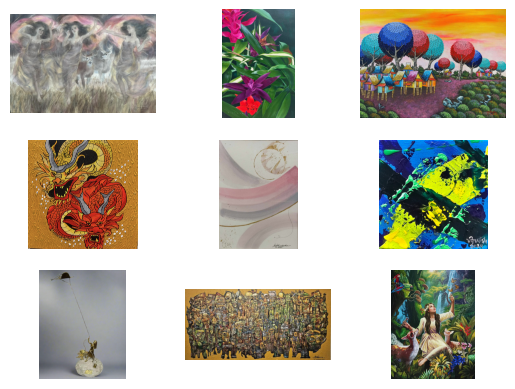

In [12]:
files = os.listdir("/content/drive/MyDrive/image_dataset/image_folder_1")

for i in range(9):
    img = Image.open(f"/content/drive/MyDrive/image_dataset/image_folder_1/{random.choice(files)}")
    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.axis("off")

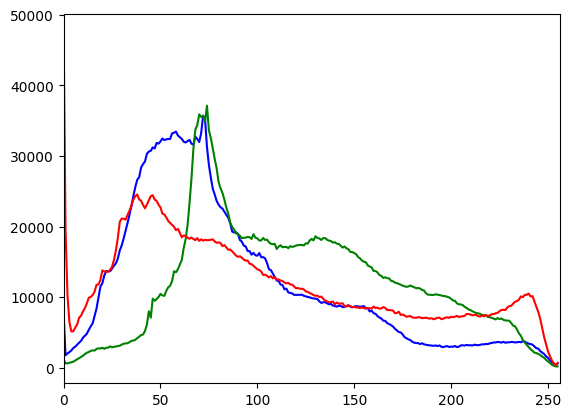

In [13]:
img = cv2.imread("/content/drive/MyDrive/image_dataset/image_folder_1/100_104_Dancing_Divas_II.jpg")

colors = ("b","g","r")
for i,col in enumerate(colors):
    hist = cv2.calcHist([img],[i],None,[256],[0,256])
    plt.plot(hist,color=col)
    plt.savefig(f"/content/drive/MyDrive/image_dataset/Visualizations/hist_{col}.png")
    plt.xlim([0,256])
plt.show()

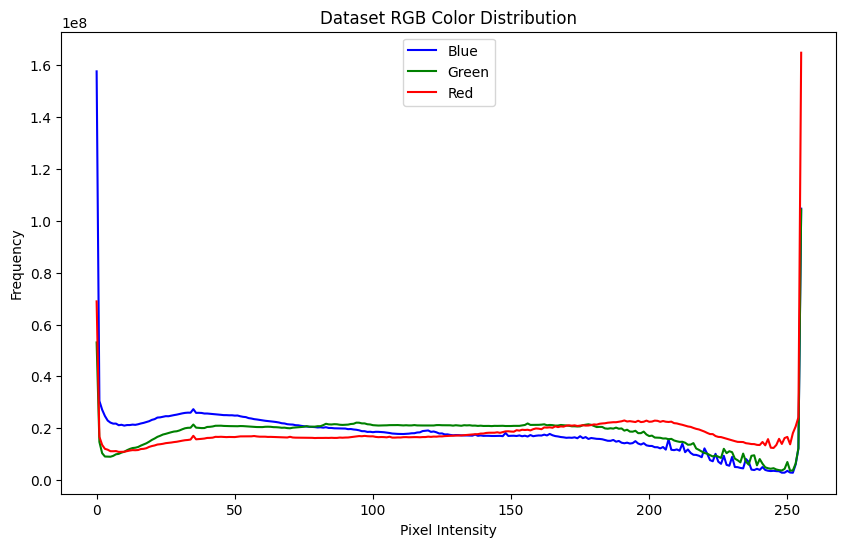

In [14]:
if not os.path.exists("/content/drive/MyDrive/image_dataset/Visualizations"):
    os.makedirs("/content/drive/MyDrive/image_dataset/Visualizations")

image_folder = "/content/drive/MyDrive/image_dataset/image_folder_1"

# initialize accumulators
hist_b = np.zeros(256)
hist_g = np.zeros(256)
hist_r = np.zeros(256)

for file in os.listdir(image_folder):

    path = os.path.join(image_folder, file)
    img = cv2.imread(path)

    if img is None:
        continue

    for i, hist in enumerate([hist_b, hist_g, hist_r]):
        h = cv2.calcHist([img], [i], None, [256], [0,256])
        hist += h.flatten()

# Plot dataset-level color distribution
plt.figure(figsize=(10,6))
plt.plot(hist_b, color='blue', label='Blue')
plt.plot(hist_g, color='green', label='Green')
plt.plot(hist_r, color='red', label='Red')

plt.title("Dataset RGB Color Distribution")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.legend()
plt.savefig("/content/drive/MyDrive/image_dataset/Visualizations/dataset_color_distribution.png")
plt.show()

(array([1.63000e+03, 3.38500e+03, 1.97100e+03, 1.57100e+03, 1.29300e+03,
        1.21600e+03, 1.13400e+03, 1.12100e+03, 1.15200e+03, 1.12900e+03,
        1.17100e+03, 1.16200e+03, 1.18100e+03, 1.21700e+03, 1.12200e+03,
        1.21500e+03, 1.26900e+03, 1.26300e+03, 1.27500e+03, 1.22600e+03,
        1.31100e+03, 1.28400e+03, 1.27700e+03, 1.27600e+03, 1.25300e+03,
        1.31800e+03, 1.30900e+03, 1.32400e+03, 1.35700e+03, 1.34700e+03,
        1.44100e+03, 1.42400e+03, 1.41100e+03, 1.43600e+03, 1.50500e+03,
        1.47400e+03, 1.52500e+03, 1.61700e+03, 1.72700e+03, 1.84300e+03,
        2.03900e+03, 2.10600e+03, 2.22100e+03, 2.37600e+03, 2.74600e+03,
        2.97300e+03, 3.21100e+03, 3.70100e+03, 4.21800e+03, 4.14900e+03,
        4.28400e+03, 4.26500e+03, 4.12600e+03, 4.08200e+03, 3.96800e+03,
        4.05000e+03, 4.14800e+03, 4.37100e+03, 4.78100e+03, 4.93400e+03,
        4.93200e+03, 4.88400e+03, 4.91900e+03, 4.83400e+03, 4.75300e+03,
        4.86900e+03, 5.09900e+03, 5.02100e+03, 5.25

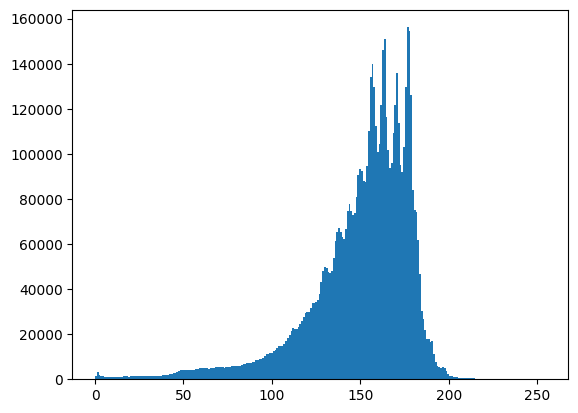

In [15]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.hist(gray.ravel(), bins=256)

##Modelling

In [16]:
class BYOLWrapper:
    def __init__(self, byol_model):
        self.model = byol_model

    @torch.no_grad()
    def encode(self, x):
        x = self.model.online_encoder(x)
        if isinstance(x, (tuple, list)):
            x = x[0]
        return x


def extract_byol_embeddings(byol_model, x):
    with torch.no_grad():
        if hasattr(byol_model.online_encoder, "net"):
            emb = byol_model.online_encoder.net(x)
        else:
            emb = byol_model.online_encoder(x)

        if isinstance(emb, (tuple, list)):
            emb = emb[0]

        return emb
#For a Frozen Encoder only
class SimpleCNN(nn.Module):
    def __init__(self, out_dim=512):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 256, 3, stride=2, padding=1),
            nn.ReLU(),
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.fc = nn.Linear(256, out_dim)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = x.flatten(1)
        x = self.fc(x)
        return x

In [17]:
class BaselinePCA(BaseEstimator, TransformerMixin):
    def __init__(self, n_components=0.95, alpha=0.7):
        self.n_components = n_components
        self.alpha = alpha
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # Add device
        backbone = SimpleCNN(out_dim=512)

        self.byol = BYOL(
          net=backbone,
          image_size=224,
          hidden_layer='fc'
        ).to(self.device) # Move BYOL model to device

        self.scaler = StandardScaler()

        self.pca = PCA(
            n_components=self.n_components,
            whiten=True,
            svd_solver='full',
            random_state=42
        )

        self.dbscan = DBSCAN(
            eps=0.7,
            metric="cosine",
            min_samples=10,
            n_jobs=-1
        )

    def fit(self, X, y=None):
        X_tensor = torch.from_numpy(X).float().to(self.device) # Convert to tensor and move to device
        with torch.no_grad():
            X_encoded = self.byol.online_encoder(X_tensor) # Use X_tensor

        if isinstance(X_encoded, tuple):
            X_encoded = X_encoded[1]

        if X_encoded.ndim == 4:
            import torch.nn.functional as F
            X_encoded = F.adaptive_avg_pool2d(X_encoded, (1, 1))

        X_processed = X_encoded.view(X_encoded.size(0), -1).cpu().detach().numpy() # Move back to CPU for sklearn

        X_scaled = self.scaler.fit_transform(X_processed)
        X_pca = self.pca.fit_transform(X_scaled)
        X_norm = normalize(X_pca)

        self.labels_ = self.dbscan.fit_predict(X_norm)
        self.embeddings_ = X_norm

        return self

    def recommend(self, query_embedding, top_k=5):
        # query_embedding is expected to be a single image (batch size 1) already preprocessed as numpy
        q_embedding_tensor = torch.from_numpy(query_embedding).float().to(self.device) # Convert to tensor and move to device
        with torch.no_grad():
            q_embedding_encoded = self.byol.online_encoder(q_embedding_tensor) # Use q_embedding_tensor

        if isinstance(q_embedding_encoded, tuple):
            q_embedding_encoded = q_embedding_encoded[1]

        if q_embedding_encoded.ndim == 4:
            import torch.nn.functional as F
            q_embedding_encoded = F.adaptive_avg_pool2d(q_embedding_encoded, (1, 1))

        query_embedding_processed = q_embedding_encoded.view(q_embedding_encoded.size(0), -1).cpu().detach().numpy() # Move back to CPU for sklearn

        q_scaled = self.scaler.transform(query_embedding_processed.reshape(1, -1))
        q_pca = self.pca.transform(q_scaled)
        q_norm = normalize(q_pca)

        sim = cosine_similarity(q_norm, self.embeddings_)[0]

        q_neighbors = cosine_similarity(q_norm, self.embeddings_)[0]
        nearest_idx = np.argmax(q_neighbors)
        q_cluster = self.labels_[nearest_idx]

        cluster_scores = np.zeros_like(sim)

        for i, label in enumerate(self.labels_):
            if label == -1:
                cluster_scores[i] = -0.2
            elif label == q_cluster:
                cluster_scores[i] = 1.0
            else:
                cluster_scores[i] = 0.0

        final_score = self.alpha * sim + (1 - self.alpha) * cluster_scores

        top_idx = np.argsort(final_score)[::-1][:top_k]

        return top_idx, final_score[top_idx]

In [18]:
class HANA(BaseEstimator, TransformerMixin):
    def __init__(self, n_components=0.95, alpha=0.07, k=15):
        self.n_components = n_components
        self.alpha = alpha
        self.k = k
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        backbone = SimpleCNN(out_dim=512)

        self.byol = BYOL(
            net=backbone,
            image_size=224,
            hidden_layer='fc'
        ).to(self.device)

        self.scaler = StandardScaler()

        self.umap = umap.UMAP(
            n_neighbors=20,
            n_components=20,
            min_dist=0.05,
            metric="cosine",
            random_state=42
        )

        self.pca = PCA(
            n_components=self.n_components,
            whiten=True,
            svd_solver="full",
            random_state=42
        )

        self.clusterer = HDBSCAN(
            min_cluster_size=10,
            metric="euclidean"
        )

    def fit(self, X, y=None):
        X = torch.from_numpy(X).float().to(self.device)

        with torch.no_grad():
            X = self.byol.online_encoder(X)

        if isinstance(X, tuple):
            X = X[1]

        if X.ndim == 4:
            X = F.adaptive_avg_pool2d(X, (1, 1))

        X = X.view(X.size(0), -1).cpu().numpy()

        X_scaled = self.scaler.fit_transform(X)
        X_umap = self.umap.fit_transform(X_scaled)
        X_pca = self.pca.fit_transform(X_umap)
        X_norm = normalize(X_pca)

        self.embeddings_ = X_norm

        self.knn = NearestNeighbors(n_neighbors=self.k, metric="cosine")
        self.knn.fit(X_norm)
        self.neighbors_ = self.knn.kneighbors(return_distance=False)

        self.labels_ = self.clusterer.fit_predict(X_norm)
        self.cluster_probs_ = self.clusterer.probabilities_

        return self

    def _jaccard_similarity(self, q_neighbors):
        q_set = set(q_neighbors)

        scores = []
        for n in self.neighbors_:
            n_set = set(n)
            inter = len(q_set & n_set)
            union = len(q_set | n_set)
            scores.append(inter / union if union != 0 else 0)

        return np.array(scores)

    def recommend(self, query_embedding, top_k=5):
        if isinstance(query_embedding, np.ndarray):
            query_embedding = torch.from_numpy(query_embedding).float()

        query_embedding = query_embedding.to(self.device)

        with torch.no_grad():
            q = self.byol.online_encoder(query_embedding)

        if isinstance(q, tuple):
            q = q[1]

        if q.ndim == 4:
            q = F.adaptive_avg_pool2d(q, (1, 1))

        q = q.view(q.size(0), -1).cpu().numpy()

        q_scaled = self.scaler.transform(q.reshape(1, -1))
        q_umap = self.umap.transform(q_scaled)
        q_pca = self.pca.transform(q_umap)
        q_norm = normalize(q_pca)

        cosine_scores = cosine_similarity(q_norm, self.embeddings_)[0]

        q_neighbors = self.knn.kneighbors(q_norm, return_distance=False)[0]
        jaccard_scores = self._jaccard_similarity(q_neighbors)

        def softmax(x):
            e = np.exp(x - np.max(x))
            return e / e.sum()

        cosine_scores = softmax(cosine_scores)
        jaccard_scores = softmax(jaccard_scores)

        final_scores = (
            self.alpha * cosine_scores +
            (1 - self.alpha) * jaccard_scores
        )

        q_cluster = self.labels_[np.argmax(final_scores)]

        cluster_bonus = np.array([
            0.1 * self.cluster_probs_[i] if label == q_cluster else 0.0
            for i, label in enumerate(self.labels_)
        ])

        final_scores += cluster_bonus

        top_idx = np.argsort(final_scores)[::-1][:top_k]

        return top_idx, final_scores[top_idx]

In [19]:
class CLIPImageEncoder:
    def __init__(self, device=None):
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        # We don't need to store the preprocess object here as inputs will be preprocessed tensors
        self.model, _ = openai_clip.load("ViT-B/32", device=self.device)
        self.model.eval()

        backbone = SimpleCNN(out_dim=512)

        self.byol = BYOL(
            net=backbone,
            image_size=224,
            hidden_layer='fc'
        ).to(self.device)

    @torch.no_grad()
    def encode(self, images_tensor): # Expects an already preprocessed torch.Tensor (N, C, H, W)
        # For CLIP: directly use the preprocessed tensor
        clip_emb = self.model.encode_image(images_tensor)

        # For BYOL: also directly use the preprocessed tensor
        byol_emb = self.byol.online_encoder(images_tensor)
        if isinstance(byol_emb, tuple):
            byol_emb = byol_emb[1]

        if byol_emb.ndim == 4:
            byol_emb = F.adaptive_avg_pool2d(byol_emb, (1, 1))

        byol_emb = byol_emb.view(byol_emb.size(0), -1)

        clip_emb = F.normalize(clip_emb, dim=-1)
        byol_emb = F.normalize(byol_emb, dim=-1)

        return F.normalize(torch.cat([clip_emb, byol_emb], dim=-1), dim=-1)

    def similarity(self, query_emb, db_emb):
        query_emb = F.normalize(query_emb, dim=-1)
        db_emb = F.normalize(db_emb, dim=-1)
        return torch.matmul(query_emb, db_emb.T)

    def recommend(self, query_emb, db_emb, top_k=5):
        if query_emb.ndim == 1:
            query_emb = query_emb.unsqueeze(0)

        scores = self.similarity(query_emb, db_emb)[0]
        top_idx = torch.argsort(scores, descending=True)[:top_k]

        return top_idx, scores[top_idx]

#Inference Time and Model Results

In [20]:
baseline = BaselinePCA(n_components=0.95, alpha=0.7)
hana = HANA(n_components=0.95, alpha=0.07, k=15)
clip_encoder = CLIPImageEncoder()

mlflow.set_experiment("Model Experiments and Results")

models = {
    "BaselinePCA": baseline,
    "HANA": hana,
    "CLIP": clip_encoder
}

def precision_at_k(relevant, retrieved, k):
    retrieved_k = retrieved[:k]
    return len(set(retrieved_k) & set(relevant)) / k

def recall_at_k(relevant, retrieved, k):
    retrieved_k = retrieved[:k]
    return len(set(retrieved_k) & set(relevant)) / len(relevant) if len(relevant) > 0 else 0.0

for model_name, model in models.items():
    with mlflow.start_run(run_name=f"{model_name}_run"):

        if model_name == "CLIP":
            # Convert numpy arrays to tensors and move to device before passing to CLIP.encode
            train_tensor = torch.from_numpy(train).float().to(model.device)
            val_tensor = torch.from_numpy(validate).float().to(model.device)
            train_emb = model.encode(train_tensor).cpu().numpy() # Convert back to numpy for sklearn metrics
            val_emb = model.encode(val_tensor).cpu().numpy() # Convert back to numpy for sklearn metrics
        else:
            model.fit(train) # train is numpy, fit handles conversion to tensor internally
            train_emb = model.embeddings_
            val_emb = model.embeddings_

        mlflow.log_param("model_name", model_name)
        mlflow.log_param("train_size", len(train))
        mlflow.log_param("val_size", len(validate))
        mlflow.log_param("embedding_dim", train_emb.shape[1])

        train_norm = np.linalg.norm(train_emb, axis=1)
        val_norm = np.linalg.norm(val_emb, axis=1)

        mlflow.log_metric("train_mean_norm", float(np.mean(train_norm)))
        mlflow.log_metric("train_std_norm", float(np.std(train_norm)))
        mlflow.log_metric("val_mean_norm", float(np.mean(val_norm)))
        mlflow.log_metric("val_std_norm", float(np.std(val_norm)))

        train_score = float(np.mean(train_norm))
        val_score = float(np.mean(val_norm))

        mlflow.log_metric("train_score", train_score)
        mlflow.log_metric("val_score", val_score)

        mlflow.log_metric("generalization_gap", float(train_score - val_score))
        print(f"Generalization Gap: {float(train_score - val_score)}")
        k = 10
        precision_scores = []
        recall_scores = []

        for i in range(len(val_emb)):
            query = val_emb[i].reshape(1, -1)

            sims = np.dot(query, val_emb.T)[0]
            retrieved = np.argsort(sims)[::-1]

            # Calculate relevant items based on true nearest neighbors in the embedding space
            # Exclude the query itself from relevant items if it's always the closest with distance 0
            distances = np.linalg.norm(val_emb - val_emb[i], axis=1)
            # Get indices of the k smallest distances, excluding the query itself (distance 0)
            relevant_indices_all = np.argsort(distances)
            # Filter out the query index if it's among the top k (it usually is)
            relevant = [idx for idx in relevant_indices_all if idx != i][:k]
            # If there are not enough relevant items after removing query, fill with next closest
            if len(relevant) < k:
                # This case should ideally not happen if k is small compared to dataset size
                # but handling it defensively
                relevant_full = relevant_indices_all[relevant_indices_all != i]
                relevant = relevant_full[:k] if len(relevant_full) >= k else relevant_full

            precision_scores.append(precision_at_k(relevant, retrieved, k))
            recall_scores.append(recall_at_k(relevant, retrieved, k))

        mlflow.log_metric("precision_k", float(np.mean(precision_scores)))
        mlflow.log_metric("recall_k", float(np.mean(recall_scores)))

        print(model_name)
        print("precision@k:", float(np.mean(precision_scores)))
        print("recall@k:", float(np.mean(recall_scores)))

        mlflow.log_param("status", "completed")

100%|███████████████████████████████████████| 338M/338M [00:13<00:00, 26.8MiB/s]
2026/04/13 16:03:14 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/13 16:03:14 INFO mlflow.store.db.utils: Updating database tables
2026/04/13 16:03:16 INFO mlflow.tracking.fluent: Experiment with name 'Model Experiments and Results' does not exist. Creating a new experiment.


Generalization Gap: 0.0
BaselinePCA
precision@k: 0.9000000000000002
recall@k: 0.9000000000000002
Generalization Gap: 0.0
HANA
precision@k: 0.9000000000000002
recall@k: 0.9000000000000002
Generalization Gap: 0.0
CLIP
precision@k: 0.009137426900584795
recall@k: 0.009137426900584795


##Test Data Results

In [22]:
def get_embeddings_in_batches(model, data, batch_size):
    all_embeddings = []
    # Ensure data is a numpy array for consistent slicing
    if not isinstance(data, np.ndarray):
        data = np.array(data)

    for i in range(0, len(data), batch_size):
        batch_data = data[i:i + batch_size]
        # Convert numpy batch to torch tensor and move to model's device
        batch_tensor = torch.from_numpy(batch_data).float().to(model.device)
        with torch.no_grad():
            embeddings = model.encode(batch_tensor)
            all_embeddings.append(embeddings.cpu().numpy())
    return np.concatenate(all_embeddings, axis=0)

results = {}

for model_name, model in models.items():
    with mlflow.start_run(run_name=f"{model_name}_run"):
        model.byol.eval()

        if model_name == "CLIP":
            batch_size = 32
            train_emb = get_embeddings_in_batches(model, train, batch_size=batch_size)
            test_emb = get_embeddings_in_batches(model, test, batch_size=batch_size)

        else:
            model.fit(train)

            train_emb = model.embeddings_

            test_tensor = torch.from_numpy(test).float().to(model.device)
            with torch.no_grad():
                test_encoded = model.byol.online_encoder(test_tensor)

            if isinstance(test_encoded, tuple):
                test_encoded = test_encoded[1]

            if test_encoded.ndim == 4:
                import torch.nn.functional as F
                test_encoded = F.adaptive_avg_pool2d(test_encoded, (1, 1))

            test_processed = test_encoded.view(test_encoded.size(0), -1).cpu().detach().numpy()
            test_scaled = model.scaler.transform(test_processed)

            if model_name == "HANA":
                test_umap = model.umap.transform(test_scaled)
                test_pca = model.pca.transform(test_umap)
            else:
                test_pca = model.pca.transform(test_scaled)

            test_emb = normalize(test_pca)

        mlflow.log_param("model_name", model_name)
        mlflow.log_param("train_size", len(train))
        mlflow.log_param("test_size", len(test))
        mlflow.log_param("embedding_dim", train_emb.shape[1])

        train_norm = np.linalg.norm(train_emb, axis=1)
        test_norm = np.linalg.norm(test_emb, axis=1)

        mlflow.log_metric("train_mean_norm", float(np.mean(train_norm)))
        mlflow.log_metric("train_std_norm", float(np.std(train_norm)))
        mlflow.log_metric("test_mean_norm", float(np.mean(test_norm)))
        mlflow.log_metric("test_std_norm", float(np.std(test_norm)))

        train_score = float(np.mean(train_norm))
        test_score = float(np.mean(test_norm))

        mlflow.log_metric("train_score", train_score)
        mlflow.log_metric("test_score", test_score)
        mlflow.log_metric("generalization_gap", float(train_score - test_score))

        print(f"Generalization Gap: {float(train_score - test_score)}")

        k = 10
        individual_precision_scores = []
        individual_recall_scores = []
        individual_graph_scores = []

        for i in range(len(test_emb)):
            query = test_emb[i].reshape(1, -1)

            sims = np.dot(query, train_emb.T)[0]
            retrieved = np.argsort(sims)[::-1]

            distances = np.linalg.norm(train_emb - query, axis=1)
            relevant = np.argsort(distances)[:k]

            individual_precision_scores.append(precision_at_k(relevant, retrieved, k))
            individual_recall_scores.append(recall_at_k(relevant, retrieved, k))

            retrieved_vecs = train_emb[retrieved[:k]]
            pairwise_sim = cosine_similarity(retrieved_vecs)
            individual_graph_scores.append(np.mean(pairwise_sim))

        mlflow.log_metric("precision_k", float(np.mean(individual_precision_scores)))
        mlflow.log_metric("recall_k", float(np.mean(individual_recall_scores)))
        mlflow.log_metric("graph_consistency", float(np.mean(individual_graph_scores)))

        print(model_name)
        print("precision@k:", float(np.mean(individual_precision_scores)))
        print("recall@k:", float(np.mean(individual_recall_scores)))
        print("graph_consistency:", float(np.mean(individual_graph_scores)))

        mlflow.log_param("status", "completed")

        results[model_name] = {
            "precision": np.array(individual_precision_scores),
            "recall": np.array(individual_recall_scores),
            "graph_consistency": np.array(individual_graph_scores)
        }

Generalization Gap: 0.0
BaselinePCA
precision@k: 1.0
recall@k: 1.0
graph_consistency: 0.9868189096450806
Generalization Gap: 0.0
HANA
precision@k: 0.9997807017543858
recall@k: 0.9997807017543858
graph_consistency: 0.9998178482055664
Generalization Gap: 0.0
CLIP
precision@k: 0.01652046783625731
recall@k: 0.01652046783625731
graph_consistency: 1.0


##Statistical Testing

In [23]:
from scipy.stats import ttest_rel, wilcoxon

def bootstrap_ci(data, n_boot=5000, alpha=0.05):
    data = np.array(data)
    n = len(data)
    means = []

    for _ in range(n_boot):
        sample = np.random.choice(data, size=n, replace=True)
        means.append(np.mean(sample))

    lower = np.percentile(means, 100 * (alpha / 2))
    upper = np.percentile(means, 100 * (1 - alpha / 2))
    return lower, upper


def cohens_d(x, y):
    x = np.array(x)
    y = np.array(y)
    pooled_std = np.sqrt((np.std(x) ** 2 + np.std(y) ** 2) / 2)
    return (np.mean(x) - np.mean(y)) / pooled_std


def run_full_stats(results, metric):
    models = list(results.keys())
    base_model = models[0]

    print(f"\n\n================ {metric.upper()} =================")

    base_data = results[base_model][metric]
    base_ci = bootstrap_ci(base_data)

    print(f"\nBASE: {base_model}")
    print(f"Mean: {np.mean(base_data):.6f}")
    print(f"CI: {base_ci}")

    for m in models[1:]:
        comp_data = results[m][metric]

        t_stat, t_p = ttest_rel(comp_data, base_data)
        w_stat, w_p = wilcoxon(comp_data, base_data)

        comp_ci = bootstrap_ci(comp_data)
        d = cohens_d(comp_data, base_data)

        print(f"\nMODEL: {m} vs {base_model}")
        print(f"Mean: {np.mean(comp_data):.6f}")
        print(f"CI: {comp_ci}")

        print(f"Paired t-test: t={t_stat:.6f}, p={t_p:.6f}")
        print(f"Wilcoxon test:  w={w_stat:.6f}, p={w_p:.6f}")
        print(f"Cohen's d: {d:.6f}")


def run_all_tests(results):
    run_full_stats(results, "precision")
    run_full_stats(results, "recall")
    run_full_stats(results, "graph_consistency")

In [24]:
run_all_tests(results)



================ PRECISION =================

BASE: BaselinePCA
Mean: 1.000000
CI: (np.float64(1.0), np.float64(1.0))

MODEL: HANA vs BaselinePCA
Mean: 0.999781
CI: (np.float64(0.9994883040935674), np.float64(1.0))
Paired t-test: t=-1.733319, p=0.083264
Wilcoxon test:  w=0.000000, p=0.083265
Cohen's d: -0.066299

MODEL: CLIP vs BaselinePCA
Mean: 0.016520
CI: (np.float64(0.012792397660818713), np.float64(0.020614035087719296))
Paired t-test: t=-488.278911, p=0.000000
Wilcoxon test:  w=0.000000, p=0.000000
Cohen's d: -18.676638


================ RECALL =================

BASE: BaselinePCA
Mean: 1.000000
CI: (np.float64(1.0), np.float64(1.0))

MODEL: HANA vs BaselinePCA
Mean: 0.999781
CI: (np.float64(0.9994883040935674), np.float64(1.0))
Paired t-test: t=-1.733319, p=0.083264
Wilcoxon test:  w=0.000000, p=0.083265
Cohen's d: -0.066299

MODEL: CLIP vs BaselinePCA
Mean: 0.016520
CI: (np.float64(0.012646198830409357), np.float64(0.02054093567251462))
Paired t-test: t=-488.278911, p=0.0000

## Stress Testing

In [25]:
def add_noise(x, noise_level=0.9):
    noise = torch.randn_like(x) * noise_level
    return x + noise

def evaluate_embeddings(emb, k=10):
    scores = []

    for i in range(len(emb)):
        query = emb[i].reshape(1, -1)
        sims = np.dot(query, emb.T)[0]
        retrieved = np.argsort(sims)[::-1]

        scores.append(np.mean(sims[retrieved[:k]]))

    return np.mean(scores)

def graph_consistency(emb, k=10):
    scores = []

    for i in range(len(emb)):
        sims = np.dot(emb[i].reshape(1, -1), emb.T)[0]
        retrieved = np.argsort(sims)[::-1][:k]

        vecs = emb[retrieved]
        sim_matrix = cosine_similarity(vecs)
        scores.append(np.mean(sim_matrix))

    return np.mean(scores)

def stress_test(model, test_data):
    model.byol.eval()

    test_tensor = torch.from_numpy(test_data).float().to(model.device)

    with torch.no_grad():
        clean_emb = model.byol.online_encoder(test_tensor)

    if isinstance(clean_emb, tuple):
        clean_emb = clean_emb[1]

    if clean_emb.ndim == 4:
        import torch.nn.functional as F
        clean_emb = F.adaptive_avg_pool2d(clean_emb, (1, 1))

    clean_emb = clean_emb.view(clean_emb.size(0), -1).cpu().numpy()

    noisy_tensor = add_noise(test_tensor, 0.2)

    with torch.no_grad():
        noisy_emb = model.byol.online_encoder(noisy_tensor)

    if isinstance(noisy_emb, tuple):
        noisy_emb = noisy_emb[1]

    if noisy_emb.ndim == 4:
        import torch.nn.functional as F
        noisy_emb = F.adaptive_avg_pool2d(noisy_emb, (1, 1))

    noisy_emb = noisy_emb.view(noisy_emb.size(0), -1).cpu().numpy()

    return {
        "clean_score": evaluate_embeddings(clean_emb),
        "noisy_score": evaluate_embeddings(noisy_emb),
        "clean_graph": graph_consistency(clean_emb),
        "noisy_graph": graph_consistency(noisy_emb),
        "retrieval_drop": evaluate_embeddings(clean_emb) - evaluate_embeddings(noisy_emb),
        "graph_drop": graph_consistency(clean_emb) - graph_consistency(noisy_emb)
    }

In [26]:
results = {}

for name, model in models.items():
    print(name)
    results[name] = stress_test(model, test)
    print(pd.DataFrame([results[name]]))


BaselinePCA
   clean_score  noisy_score  clean_graph  noisy_graph  retrieval_drop  \
0     0.956392     0.962192          1.0     0.999977         -0.0058   

   graph_drop  
0    0.000023  
HANA
   clean_score  noisy_score  clean_graph  noisy_graph  retrieval_drop  \
0      1.30798     1.311352          1.0     0.999985       -0.003372   

   graph_drop  
0    0.000015  
CLIP
   clean_score  noisy_score  clean_graph  noisy_graph  retrieval_drop  \
0     0.974028     0.983464          1.0     0.999981       -0.009436   

   graph_drop  
0    0.000019  


In [27]:
import numpy as np
import torch

def add_adversarial_noise(x, eps=0.8):
    noise = torch.randn_like(x)
    noise = noise / (torch.norm(noise, dim=1, keepdim=True) + 1e-8)
    return x + eps * noise


def topk_indices(sim_matrix, k=10):
    return np.argsort(sim_matrix)[::-1][:k]


def topk_overlap(a, b):
    return len(set(a) & set(b)) / len(a)


def rank_flip_rate(clean_emb, noisy_emb, k=10):
    flips = []

    for i in range(len(clean_emb)):
        clean_sim = np.dot(clean_emb[i], clean_emb.T)
        noisy_sim = np.dot(noisy_emb[i], noisy_emb.T)

        clean_topk = topk_indices(clean_sim, k)
        noisy_topk = topk_indices(noisy_sim, k)

        flips.append(len(set(clean_topk) ^ set(noisy_topk)) / k)

    return np.mean(flips)


def robustness_metrics(clean_emb, noisy_emb, k=10):
    overlap_scores = []
    drop_scores = []

    for i in range(len(clean_emb)):
        clean_sim = np.dot(clean_emb[i], clean_emb.T)
        noisy_sim = np.dot(noisy_emb[i], noisy_emb.T)

        clean_topk = topk_indices(clean_sim, k)
        noisy_topk = topk_indices(noisy_sim, k)

        overlap_scores.append(topk_overlap(clean_topk, noisy_topk))

        drop_scores.append(
            np.mean(clean_sim[clean_topk]) - np.mean(noisy_sim[noisy_topk])
        )

    return {
        "topk_overlap": np.mean(overlap_scores),
        "retrieval_drop": np.mean(drop_scores),
        "rank_flip_rate": rank_flip_rate(clean_emb, noisy_emb, k)
    }

In [28]:
def stress_test(model, test_data, noise_level=0.8):
    model.byol.eval()

    test_tensor = torch.from_numpy(test_data).float().to(model.device)

    with torch.no_grad():
        clean = model.byol.online_encoder(test_tensor)

    if isinstance(clean, tuple):
        clean = clean[1]

    if clean.ndim == 4:
        import torch.nn.functional as F
        clean = F.adaptive_avg_pool2d(clean, (1, 1))

    clean_emb = clean.view(clean.size(0), -1).cpu().numpy()

    noisy_tensor = add_adversarial_noise(test_tensor, noise_level)

    with torch.no_grad():
        noisy = model.byol.online_encoder(noisy_tensor)

    if isinstance(noisy, tuple):
        noisy = noisy[1]

    if noisy.ndim == 4:
        import torch.nn.functional as F
        noisy = F.adaptive_avg_pool2d(noisy, (1, 1))

    noisy_emb = noisy.view(noisy.size(0), -1).cpu().numpy()

    clean_metrics = robustness_metrics(clean_emb, clean_emb)
    noisy_metrics = robustness_metrics(clean_emb, noisy_emb)

    return {
        "clean_topk_overlap": clean_metrics["topk_overlap"],
        "noisy_topk_overlap": noisy_metrics["topk_overlap"],
        "overlap_drop": clean_metrics["topk_overlap"] - noisy_metrics["topk_overlap"],

        "clean_rank_flip_rate": clean_metrics["rank_flip_rate"],
        "noisy_rank_flip_rate": noisy_metrics["rank_flip_rate"],
        "rank_flip_increase": noisy_metrics["rank_flip_rate"] - clean_metrics["rank_flip_rate"],

        "retrieval_drop": noisy_metrics["retrieval_drop"]
    }

In [29]:
results = {}

for name, model in models.items():
    print(name)
    results[name] = stress_test(model, test)
    print(pd.DataFrame([results[name]]))


BaselinePCA
   clean_topk_overlap  noisy_topk_overlap  overlap_drop  clean_rank_flip_rate  \
0                 1.0                 0.0           1.0                   0.0   

   noisy_rank_flip_rate  rank_flip_increase  retrieval_drop  
0                   2.0                 2.0       -0.024259  
HANA
   clean_topk_overlap  noisy_topk_overlap  overlap_drop  clean_rank_flip_rate  \
0                 1.0                 0.0           1.0                   0.0   

   noisy_rank_flip_rate  rank_flip_increase  retrieval_drop  
0                   2.0                 2.0       -0.013478  
CLIP
   clean_topk_overlap  noisy_topk_overlap  overlap_drop  clean_rank_flip_rate  \
0                 1.0                 0.0           1.0                   0.0   

   noisy_rank_flip_rate  rank_flip_increase  retrieval_drop  
0                   2.0                 2.0       -0.030328  


In [30]:
def get_embeddings(model, data):
    model.byol.eval()

    x = torch.from_numpy(data).float().to(model.device)

    with torch.no_grad():
        emb = model.byol.online_encoder(x)

    if isinstance(emb, tuple):
        emb = emb[1]

    if emb.ndim == 4:
        import torch.nn.functional as F
        emb = F.adaptive_avg_pool2d(emb, (1, 1))

    emb = emb.view(emb.size(0), -1)
    emb = torch.nn.functional.normalize(emb, dim=1)

    return emb.cpu().numpy()


def add_adversarial_noise(x, eps=0.8):
    noise = torch.randn_like(x)
    noise = noise / (torch.norm(noise, dim=1, keepdim=True) + 1e-8)
    return x + eps * noise


def get_rank_matrix(emb, k=10):
    sims = np.dot(emb, emb.T)
    np.fill_diagonal(sims, -np.inf)
    return np.argsort(-sims, axis=1)[:, :k]


def compute_overlap(clean_rank, noisy_rank, k=10):
    scores = []
    for i in range(len(clean_rank)):
        scores.append(len(set(clean_rank[i]) & set(noisy_rank[i])) / k)
    return np.mean(scores)


def compute_flip_rate(clean_rank, noisy_rank, k=10):
    flips = []
    for i in range(len(clean_rank)):
        flips.append(len(set(clean_rank[i]) ^ set(noisy_rank[i])) / k)
    return np.mean(flips)


def stress_test_v3(model, test_data, k=10, noise_level=0.8):
    clean_emb = get_embeddings(model, test_data)

    test_tensor = torch.from_numpy(test_data).float().to(model.device)
    noisy_tensor = add_adversarial_noise(test_tensor, noise_level)

    noisy_emb = get_embeddings(model, noisy_tensor.cpu().numpy())

    clean_rank = get_rank_matrix(clean_emb, k)
    noisy_rank = get_rank_matrix(noisy_emb, k)

    return {
        "topk_overlap": compute_overlap(clean_rank, noisy_rank, k),
        "rank_flip_rate": compute_flip_rate(clean_rank, noisy_rank, k)
    }

In [31]:
v3_results = {}

for name, model in models.items():
    print(name)
    v3_results[name] = stress_test(model, test)
    print(pd.DataFrame([v3_results[name]]))

BaselinePCA
   clean_topk_overlap  noisy_topk_overlap  overlap_drop  clean_rank_flip_rate  \
0                 1.0                 0.0           1.0                   0.0   

   noisy_rank_flip_rate  rank_flip_increase  retrieval_drop  
0                   2.0                 2.0       -0.024091  
HANA
   clean_topk_overlap  noisy_topk_overlap  overlap_drop  clean_rank_flip_rate  \
0                 1.0                 0.0           1.0                   0.0   

   noisy_rank_flip_rate  rank_flip_increase  retrieval_drop  
0                   2.0                 2.0       -0.013397  
CLIP
   clean_topk_overlap  noisy_topk_overlap  overlap_drop  clean_rank_flip_rate  \
0                 1.0                 0.0           1.0                   0.0   

   noisy_rank_flip_rate  rank_flip_increase  retrieval_drop  
0                   2.0                 2.0       -0.030775  


## Impossibility Testing

In [33]:
def impossibility_test(emb, k=10):
    n = len(emb)

    results = {}

    sims = np.dot(emb, emb.T)
    np.fill_diagonal(sims, -np.inf)
    rank = np.argsort(-sims, axis=1)[:, :k]

    shuffled_emb = emb.copy()
    np.random.shuffle(shuffled_emb)

    sims_shuffled = np.dot(shuffled_emb, shuffled_emb.T)
    np.fill_diagonal(sims_shuffled, -np.inf)
    rank_shuffled = np.argsort(-sims_shuffled, axis=1)[:, :k]

    results["shuffle_overlap"] = np.mean([
        len(set(rank[i]) & set(rank_shuffled[i])) / k
        for i in range(n)
    ])

    collapsed_emb = np.ones_like(emb)

    sims_collapsed = np.dot(collapsed_emb, collapsed_emb.T)
    np.fill_diagonal(sims_collapsed, -np.inf)
    rank_collapsed = np.argsort(-sims_collapsed, axis=1)[:, :k]

    results["collapse_overlap"] = np.mean([
        len(set(rank[i]) & set(rank_collapsed[i])) / k
        for i in range(n)
    ])

    random_emb = np.random.randn(*emb.shape)

    sims_random = np.dot(random_emb, random_emb.T)
    np.fill_diagonal(sims_random, -np.inf)
    rank_random = np.argsort(-sims_random, axis=1)[:, :k]

    results["random_overlap"] = np.mean([
        len(set(rank[i]) & set(rank_random[i])) / k
        for i in range(n)
    ])

    return results

imp_results = {}

for name, model in models.items():
    print(name)

    if name == "CLIP":
        train_tensor = torch.from_numpy(train).float().to(model.device)
        emb = model.encode(train_tensor).cpu().numpy()
    else:
        emb = get_embeddings(model, train)

    imp_results[name] = impossibility_test(emb)

    print(pd.DataFrame([imp_results[name]]))

BaselinePCA
   shuffle_overlap  collapse_overlap  random_overlap
0         0.008845           0.00519        0.007822
HANA
   shuffle_overlap  collapse_overlap  random_overlap
0         0.010307          0.011915        0.008699
CLIP
   shuffle_overlap  collapse_overlap  random_overlap
0         0.009211          0.002339        0.007018


##Causal Inference

In [34]:
!pip install dowhy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.1/403.1 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.3/204.3 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 31.4 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3
  Attempting uninstall: cvxpy
    Found existing installation: cvxpy 1.6.7
    Uninstalling cvxpy-1.6.7:
      Successfully uninstalled cvxpy-1.6.7


In [41]:



# Helper function to get embeddings for non-CLIP models
def get_test_embeddings(model, test_data):
    test_tensor = torch.from_numpy(test_data).float().to(model.device)
    with torch.no_grad():
        test_encoded = model.byol.online_encoder(test_tensor)

    if isinstance(test_encoded, tuple):
        test_encoded = test_encoded[1]

    if test_encoded.ndim == 4:
        test_encoded = F.adaptive_avg_pool2d(test_encoded, (1, 1))

    test_processed = test_encoded.view(test_encoded.size(0), -1).cpu().detach().numpy()
    test_scaled = model.scaler.transform(test_processed)

    if isinstance(model, HANA):
        test_umap = model.umap.transform(test_scaled)
        test_pca = model.pca.transform(test_umap)
    else:
        test_pca = model.pca.transform(test_scaled)

    test_emb = normalize(test_pca)
    return test_emb

# Helper function for graph consistency (from 7yN6_ea-UGeG)
def graph_consistency(emb, k=10):
    scores = []
    for i in range(len(emb)):
        sims = np.dot(emb[i].reshape(1, -1), emb.T)[0]
        retrieved = np.argsort(sims)[::-1][:k]
        vecs = emb[retrieved]
        sim_matrix = cosine_similarity(vecs)
        scores.append(np.mean(sim_matrix))
    return np.mean(scores)


records = []
k = 10 # Define k for consistency

for model_name, model in models.items():
    model.byol.eval() # Set BYOL to eval mode

    if model_name == "CLIP":
        train_emb = get_embeddings_in_batches(model, train, batch_size=32)
        test_emb = get_embeddings_in_batches(model, test, batch_size=32)
    else:
        model.fit(train)
        train_emb = model.embeddings_
        test_emb = get_test_embeddings(model, test)

    for i in range(len(test_emb)):
        query = test_emb[i].reshape(1, -1)

        sims = np.dot(query, train_emb.T)[0]
        retrieved_indices = np.argsort(sims)[::-1]

        distances = np.linalg.norm(train_emb - query, axis=1)
        relevant_indices = np.argsort(distances)[:k]

        precision = precision_at_k(relevant_indices, retrieved_indices, k)

        retrieved_vecs_for_graph = train_emb[retrieved_indices[:k]]
        pairwise_sim_for_graph = cosine_similarity(retrieved_vecs_for_graph)
        graph_score = np.mean(pairwise_sim_for_graph)

        records.append({
            "model": model_name,
            "treatment": {"BaselinePCA":0, "HANA":1, "CLIP":2}[model_name],
            "precision": precision,
            "graph": graph_score
        })

df = pd.DataFrame(records)

model_causal = CausalModel(
    data=df,
    treatment="treatment",
    outcome="precision",
    common_causes=["graph"]
)

identified_estimand = model_causal.identify_effect()
estimate = model_causal.estimate_effect(
    identified_estimand,
    method_name="backdoor.linear_regression"
)

print(estimate)


*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
     d                          
────────────(E[precision|graph])
d[treatment]                    
Estimand assumption 1, Unconfoundedness: If U→{treatment} and U→precision then P(precision|treatment,graph,U) = P(precision|treatment,graph)

## Realized estimand
b: precision~treatment+graph
Target units: ate

## Estimate
Mean value: -0.5846641975831497



In [42]:
#Mediation Analysis
import statsmodels.formula.api as smf

# Model → Graph
med_model = smf.ols("graph ~ treatment", data=df).fit()

# Graph + Model → Precision
out_model = smf.ols("precision ~ treatment + graph", data=df).fit()

print(med_model.summary())
print(out_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  graph   R-squared:                       0.368
Model:                            OLS   Adj. R-squared:                  0.368
Method:                 Least Squares   F-statistic:                     2393.
Date:                Mon, 13 Apr 2026   Prob (F-statistic):               0.00
Time:                        16:32:31   Log-Likelihood:                 14513.
No. Observations:                4104   AIC:                        -2.902e+04
Df Residuals:                    4102   BIC:                        -2.901e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.9890      0.000   5685.591      0.0

In [39]:
res = smf.ols("graph ~ treatment", data=df).fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                  graph   R-squared:                       0.740
Model:                            OLS   Adj. R-squared:                  0.480
Method:                 Least Squares   F-statistic:                     2.845
Date:                Mon, 13 Apr 2026   Prob (F-statistic):              0.341
Time:                        16:28:40   Log-Likelihood:               0.089874
No. Observations:                   3   AIC:                             3.820
Df Residuals:                       1   BIC:                             2.017
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.1529      0.371      3.105      0.1

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 3 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


## Causal Conterfactual Test

In [49]:
import statsmodels.api as sm

df_cf = df.copy()
df_cf["graph"] = df["graph"].mean()

y_cf = out_model.predict(sm.add_constant(df_cf[["treatment","graph"]]))
print(y_cf)

0       1.256765
1       1.256765
2       1.256765
3       1.256765
4       1.256765
          ...   
4099    0.087437
4100    0.087437
4101    0.087437
4102    0.087437
4103    0.087437
Length: 4104, dtype: float64


## Model Interpretability

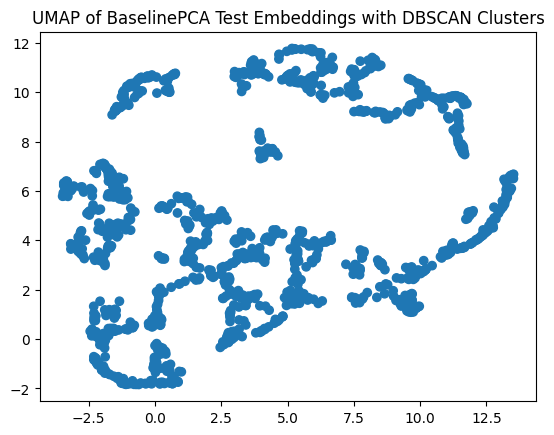

In [53]:
current_model = models["BaselinePCA"] # Using BaselinePCA for demonstration
test_embeddings_2d = get_test_embeddings(current_model, test)


test_clusterer = DBSCAN(
    eps=current_model.dbscan.eps,
    metric=current_model.dbscan.metric,
    min_samples=current_model.dbscan.min_samples,
    n_jobs=current_model.dbscan.n_jobs
)
test_labels = test_clusterer.fit_predict(test_embeddings_2d)


reducer = umap.UMAP(n_components=2)
emb_2d = reducer.fit_transform(test_embeddings_2d)

# 4. Plot the results
plt.scatter(emb_2d[:,0], emb_2d[:,1], c=test_labels, cmap='tab10')
plt.title(f"UMAP of {current_model.__class__.__name__} Test Embeddings with DBSCAN Clusters")
plt.show()

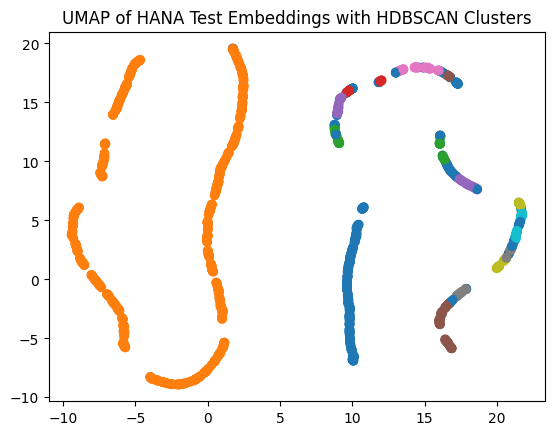

In [57]:
current_model = models["HANA"]
test_embeddings_2d = get_test_embeddings(current_model, test)

# Use HDBSCAN as defined in the HANA model
test_clusterer = HDBSCAN(
    min_cluster_size=current_model.clusterer.min_cluster_size,
    metric=current_model.clusterer.metric
)
test_labels = test_clusterer.fit_predict(test_embeddings_2d)


reducer = umap.UMAP(n_components=2)
emb_2d = reducer.fit_transform(test_embeddings_2d)

# Plot the results
plt.scatter(emb_2d[:,0], emb_2d[:,1], c=test_labels, cmap='tab10')
plt.title(f"UMAP of {current_model.__class__.__name__} Test Embeddings with HDBSCAN Clusters")
plt.show()

In [58]:
def explain_recommendation(model, query_idx, emb, k=5):
    sims = np.dot(emb[query_idx], emb.T)
    top_idx = np.argsort(sims)[::-1][1:k+1]
    return top_idx

In [62]:
#Explaining the reccomendation
query_idx = 0
for model_name, model in models.items():
    print(f"\nModel: {model_name}")
    # Get embeddings for the test data based on the model type
    if model_name == "CLIP":
        # For CLIP, use get_embeddings_in_batches, assuming it's already fitted.
        # This function also handles moving data to device and back.
        current_test_emb = get_embeddings_in_batches(model, test, batch_size=32)
    else:
        # For other models, use get_test_embeddings after fitting (which happened in previous cells)
        current_test_emb = get_test_embeddings(model, test)

    # Now call explain_recommendation with the actual embeddings
    recommendations = explain_recommendation(model, query_idx, current_test_emb, k=5)
    print(f"Top 5 recommendations for query index {query_idx}: {recommendations}")


Model: BaselinePCA
Top 5 recommendations for query index 0: [ 616 1250  284  763   69]

Model: HANA
Top 5 recommendations for query index 0: [ 284  340   70 1304   69]

Model: CLIP
Top 5 recommendations for query index 0: [340  34 959 652 721]


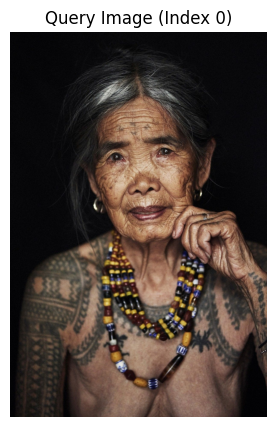


--- Recommendations for BaselinePCA ---


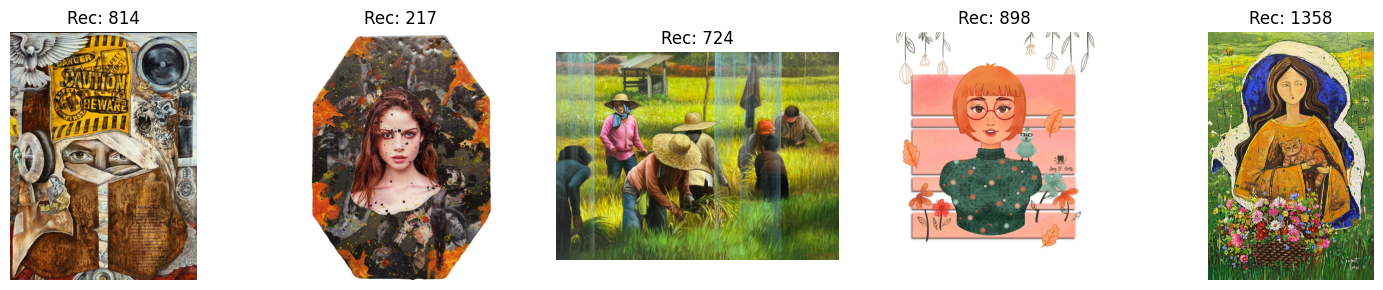


--- Recommendations for HANA ---


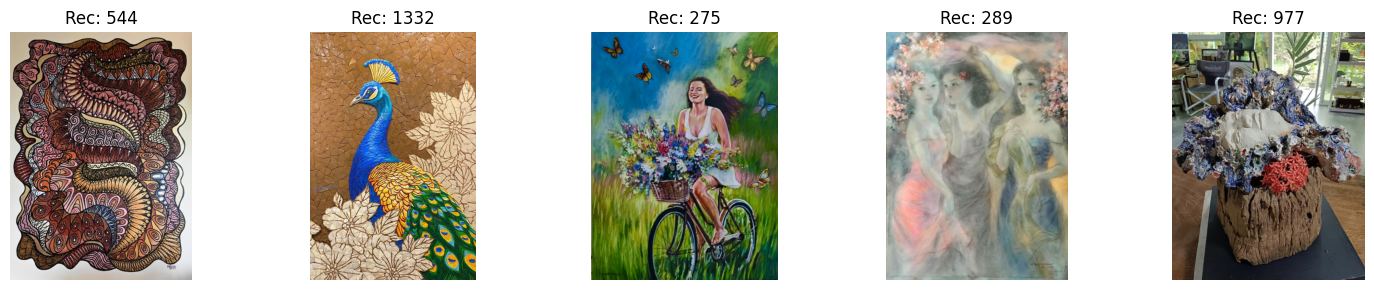


--- Recommendations for CLIP ---


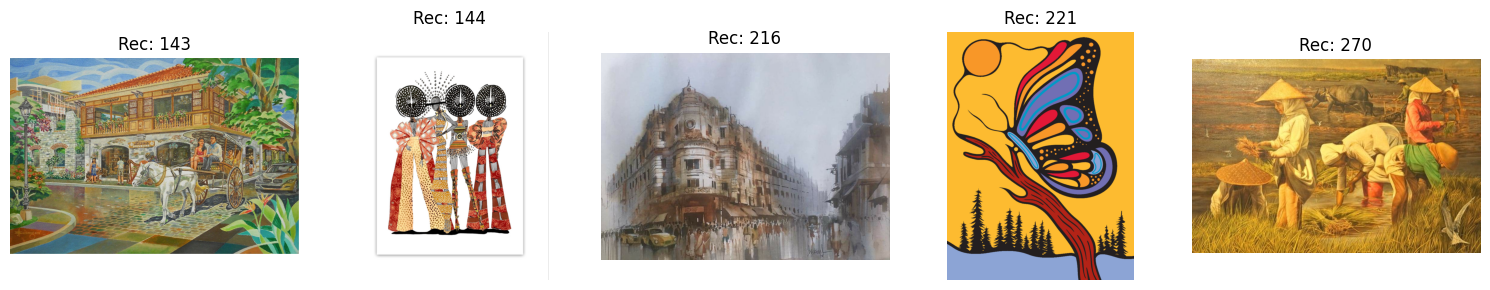

In [67]:
query_image_path = test_df.image_paths[query_idx]
query_image = Image.open(query_image_path).convert("RGB")

plt.figure(figsize=(10, 5))
plt.imshow(query_image)
plt.title(f"Query Image (Index {query_idx})")
plt.axis("off")
plt.show()

for model_name, model in models.items():
    print(f"\n--- Recommendations for {model_name} ---")
    if model_name == "CLIP":
        # For CLIP, 'recommend' is on the encoder itself, and expects torch tensors for query_emb and db_emb.
        # Re-encode the test data to get the actual embeddings used for CLIP's similarity
        test_tensor = torch.from_numpy(test).float().to(model.device)
        clip_test_emb_tensor = model.encode(test_tensor) # This is a tensor

        # The `recommend` method of CLIPImageEncoder expects tensors
        recs_tensor, scores_tensor = model.recommend(clip_test_emb_tensor[query_idx].unsqueeze(0), clip_test_emb_tensor, top_k=5)
        recommendation_indices = recs_tensor.cpu().numpy()
        # For CLIP, recommendations are from the test dataset
        source_df = test_df
    else:
        # For BaselinePCA and HANA, the 'recommend' method is part of the model object itself
        # It expects the raw preprocessed image (like 'test[query_idx]')
        # Looking at BaselinePCA.recommend and HANA.recommend, they expect query_embedding to be a single image (numpy array preprocessed)
        recommendation_indices, _ = model.recommend(test[query_idx].reshape(1, *test[query_idx].shape), top_k=5)
        # For BaselinePCA and HANA, recommendations are from the training dataset
        source_df = train_df

    fig, axes = plt.subplots(1, 5, figsize=(15, 3))
    for i, idx in enumerate(recommendation_indices):
        img_path = source_df.image_paths[idx]
        img = Image.open(img_path).convert("RGB")
        axes[i].imshow(img)
        axes[i].set_title(f"Rec: {idx}")
        axes[i].axis("off")
    plt.tight_layout()
    plt.show()

##Uplift Modelling

In [70]:
def get_precision_scores_for_model(model_name, model, train_data, test_data, k=10):
    individual_precision_scores = []

    if model_name == "CLIP":
        batch_size = 32
        train_emb = get_embeddings_in_batches(model, train_data, batch_size=batch_size)
        test_emb = get_embeddings_in_batches(model, test_data, batch_size=batch_size)
    else:
        # Refit the model to get the embeddings_ attribute if it's not present or outdated
        # This assumes model.fit modifies the model in place to set embeddings_ and other attributes
        model.fit(train_data)
        train_emb = model.embeddings_
        # get_test_embeddings is defined in sB-akB5Wpo5
        test_emb = get_test_embeddings(model, test_data)

    for i in range(len(test_emb)):
        query = test_emb[i].reshape(1, -1)
        sims = np.dot(query, train_emb.T)[0]
        retrieved = np.argsort(sims)[::-1]

        distances = np.linalg.norm(train_emb - query, axis=1)
        relevant = np.argsort(distances)[:k]

        individual_precision_scores.append(precision_at_k(relevant, retrieved, k))

    return np.array(individual_precision_scores)

# Calculate precision scores for each model for uplift analysis
baseline_precision_scores = get_precision_scores_for_model("BaselinePCA", models["BaselinePCA"], train, test)
hana_precision_scores = get_precision_scores_for_model("HANA", models["HANA"], train, test)
clip_precision_scores = get_precision_scores_for_model("CLIP", models["CLIP"], train, test)

records = []

for i in range(len(test)):

    y_base = baseline_precision_scores[i]
    y_hana = hana_precision_scores[i]
    y_clip = clip_precision_scores[i]

    records.append({
        "id": i,
        "y_base": y_base,
        "y_hana": y_hana,
        "y_clip": y_clip,
    })

df = pd.DataFrame(records)
df["uplift_hana"] = df["y_hana"] - df["y_base"]
df["uplift_clip"] = df["y_clip"] - df["y_base"]

In [71]:
print("Mean HANA uplift:", df["uplift_hana"].mean())
print("Mean CLIP uplift:", df["uplift_clip"].mean())

Mean HANA uplift: -8.605851979345953e-05
Mean CLIP uplift: -0.9922547332185886


In [73]:
print("Positive uplift %:", np.mean(df["uplift_hana"] > 0))
print("Negative uplift %:", np.mean(df["uplift_hana"] < 0))
print("Uplift std:", df["uplift_hana"].std())

Positive uplift %: 0.0
Negative uplift %: 0.0008605851979345956
Uplift std: 0.0029335732442443054


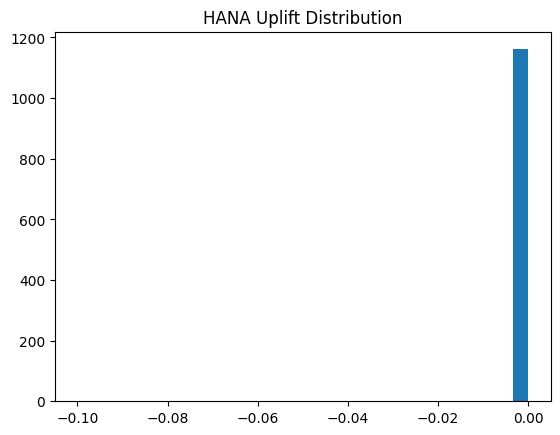

In [72]:
plt.hist(df["uplift_hana"], bins=30)
plt.title("HANA Uplift Distribution")
plt.show()

##A/B Testing

In [79]:
A = np.array(baseline_precision_scores)
B = np.array(hana_precision_scores)

diff = B - A

mean_A = A.mean()
mean_B = B.mean()
mean_diff = diff.mean()

t_stat, p_value = ss.ttest_rel(B, A)

w_stat, w_p = ss.wilcoxon(B, A)

def cohens_d(x, y):
    d = x - y
    return d.mean() / d.std()

effect_size = cohens_d(B, A)

print("===== A/B TEST RESULTS =====")
print(f"Mean A (Baseline): {mean_A:.6f}")
print(f"Mean B (HANA):     {mean_B:.6f}")
print(f"Mean Diff (B-A):   {mean_diff:.6f}")
print()
print(f"Paired t-test:     t={t_stat:.6f}, p={p_value:.6f}")
print(f"Wilcoxon test:     w={w_stat:.6f}, p={w_p:.6f}")
print(f"Cohen's d:         {effect_size:.6f}")

===== A/B TEST RESULTS =====
Mean A (Baseline): 1.000000
Mean B (HANA):     0.999914
Mean Diff (B-A):   -0.000086

Paired t-test:     t=-1.000000, p=0.317519
Wilcoxon test:     w=0.000000, p=0.317311
Cohen's d:         -0.029348
